This Jupyter notebook contains the code used to reproduce the experimental results presented in Sections **5.2** (*Comparison with baseline oversampling techniques*) and **5.4** (*Statistical Analysis*) of the manuscript. 

It also includes supplementary results reporting the number of times each synthetic data generator achieves the best performance for each evaluation metric across the 20 evaluated datasets, as well as the average rank of each generator for every evaluation metric.

All generated results are saved under the directory <small>`/K-IPO/experiments/evaluation/results`</small>. This directory contains two main subdirectories:

- <small>`tables/`</small>, which stores the performance comparison results of the evaluated synthetic data generators across the 20 datasets.

- <small>`stat_tests/`</small>, which stores all outputs related to the statistical analysis, including the **Friedman** and **post-hoc Nemenyi test** results, **pairwise Wilcoxon** comparisons, ranking tables, and the generated **critical difference (CD) diagrams**.

The execution pipeline provides informative messages reporting the output paths of all generated artifacts.


In [ ]:
import os; from pathlib import Path; from shutil import rmtree

from IPython.display import display

import pandas as pd; import numpy as np; import matplotlib.pyplot as plt

from PIL import Image

from utils import (aggregate_results, save_table, compute_winners, 
                   compute_method_metric_wins, statistical_test)

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

In [2]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 12

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

In [3]:
ROOT_DIR = Path.cwd() / "evaluation"

OUTPUT_DIR = ROOT_DIR / "results/"; 

if OUTPUT_DIR.exists():
    rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents = True)
STATS_DIR = OUTPUT_DIR / "stat_tests"; STATS_DIR.mkdir(parents = True)
TABLES_DIR = OUTPUT_DIR / "tables"; TABLES_DIR.mkdir(parents = True)

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

In [4]:
summary = aggregate_results(ROOT_DIR)

save_table(summary, os.path.join(TABLES_DIR, "mean_std_raw"))
save_table(summary, os.path.join(TABLES_DIR, "mean_std"), style = "+/- std")

dataset_metric_winners = compute_winners(summary) 
save_table(dataset_metric_winners , os.path.join(TABLES_DIR, "per_dataset_metric_winners"))

method_metric_wins = compute_method_metric_wins(dataset_metric_winners)
save_table(method_metric_wins, os.path.join(TABLES_DIR, "method_metric_wins")) 

statistical_test(summary)

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

[INFO] Saved table: /home/hpclab01/K-IPO/experiments/evaluation/results/tables/mean_std_raw.csv
[INFO] Saved table: /home/hpclab01/K-IPO/experiments/evaluation/results/tables/mean_std.csv
[INFO] Saved table: /home/hpclab01/K-IPO/experiments/evaluation/results/tables/per_dataset_metric_winners.csv
[INFO] Saved table: /home/hpclab01/K-IPO/experiments/evaluation/results/tables/method_metric_wins.csv

[INFO] Processing metric: Accuracy
[INFO] Friedman test completed (p = 3.86e-03)
[INFO] Wilcoxon pairwise tests completed
[INFO] Wilcoxon pairwise results saved: /home/hpclab01/K-IPO/experiments/evaluation/results/stat_tests/tables/Accuracy_wilcoxon_pairwise.csv
[INFO] Nemenyi posthoc test completed
[INFO] Nemenyi p-value matrix saved: /home/hpclab01/K-IPO/experiments/evaluation/results/stat_tests/tables/Accuracy_nemenyi_pvalues_matrix.csv
[INFO] Critical difference diagram saved

[INFO] Processing metric: BalancedAcc
[INFO] Friedman test completed (p = 9.79e-04)
[INFO] Wilcoxon pairwise test

In [5]:
print("[Manuscript] Tables 5 and 6: Overall performance comparison of synthetic data generation methods across the 20 evaluated datasets")

res = pd.read_csv(os.path.join(TABLES_DIR, "mean_std.csv"))

res = res.rename(columns = {
    "BalancedAcc": "Bal. Acc.",
    "kendall_tau": "Kendall's τ",
    "separability(1-N3)": "1 - N3",
    "PredictiveScore": "P",
    "Interpretability": "I"
})

for dataset, table in res.groupby("Dataset"):
    print(f"\n-> {dataset}")
    display(table[["Method", "Bal. Acc.", "F1", "MCC", "P", "I", "Kendall's τ", "1 - N3"]])

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

[Manuscript] Tables 5 and 6: Overall performance comparison of synthetic data generation methods across the 20 evaluated datasets

-> abalone


,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
0,CTGAN,0.9320 ± 0.0027,0.9251 ± 0.0037,0.8759 ± 0.0084,0.9587 ± 0.0022,0.8175 ± 0.0259,0.2572 ± 0.2054,0.8969 ± 0.0051
1,GaussianCopula,0.8436 ± 0.0000,0.8238 ± 0.0000,0.6803 ± 0.0000,0.8497 ± 0.0000,0.8095 ± 0.0000,0.8571 ± 0.0000,0.7301 ± 0.0000
2,K-IPO,0.9001 ± 0.0052,0.8854 ± 0.0056,0.7945 ± 0.0104,0.8999 ± 0.0038,20.5800 ± 37.4512,0.9835 ± 0.0313,0.9183 ± 0.0025
3,SMOTE,0.8940 ± 0.0048,0.8788 ± 0.0051,0.7821 ± 0.0092,0.8940 ± 0.0035,0.8444 ± 0.0146,0.8571 ± 0.0000,0.9045 ± 0.0024
4,TabDDPM,0.8669 ± 0.0351,0.8482 ± 0.0423,0.7487 ± 0.0776,0.9051 ± 0.0309,0.8270 ± 0.0272,-0.0214 ± 0.1013,0.8464 ± 0.0328
5,TVAE,0.9186 ± 0.0028,0.9074 ± 0.0030,0.8394 ± 0.0051,0.9470 ± 0.0019,0.7595 ± 0.0195,0.4714 ± 0.0904,0.8647 ± 0.0047



-> ai4i2020


,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
6,CTGAN,0.9567 ± 0.0097,0.9512 ± 0.0113,0.9152 ± 0.0197,0.9738 ± 0.0068,0.6318 ± 0.0891,0.2267 ± 0.2335,0.9302 ± 0.0138
7,GaussianCopula,0.9655 ± 0.0000,0.9618 ± 0.0000,0.9338 ± 0.0000,0.9793 ± 0.0000,0.8571 ± 0.0000,0.7333 ± 0.0000,0.9427 ± 0.0000
8,K-IPO,0.9812 ± 0.0016,0.9777 ± 0.0019,0.9608 ± 0.0034,0.9873 ± 0.0012,0.8666 ± 0.0301,1.0000 ± 0.0000,0.9828 ± 0.0007
9,SMOTE,0.9734 ± 0.0027,0.9688 ± 0.0030,0.9451 ± 0.0053,0.9820 ± 0.0015,0.7301 ± 0.0280,0.6000 ± 0.0000,0.9770 ± 0.0008
10,TabDDPM,0.8730 ± 0.0420,0.8558 ± 0.0482,0.7492 ± 0.0888,0.9060 ± 0.0390,0.7810 ± 0.0751,0.4667 ± 0.2266,0.8330 ± 0.0549
11,TVAE,0.9458 ± 0.0044,0.9365 ± 0.0050,0.8877 ± 0.0090,0.9628 ± 0.0032,0.6730 ± 0.0778,0.4400 ± 0.0562,0.9125 ± 0.0042


...

,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
102,CTGAN,0.9521 ± 0.0016,0.9485 ± 0.0019,0.9141 ± 0.0034,0.9672 ± 0.0012,0.7205 ± 0.0287,0.3752 ± 0.1253,0.8677 ± 0.0111
103,GaussianCopula,0.9383 ± 0.0000,0.9320 ± 0.0000,0.8859 ± 0.0000,0.9568 ± 0.0000,0.7190 ± 0.0000,0.6190 ± 0.0000,0.8405 ± 0.0000
104,K-IPO,0.9046 ± 0.0061,0.8909 ± 0.0073,0.8073 ± 0.0135,0.9227 ± 0.0066,0.7667 ± 0.0087,0.8400 ± 0.0339,0.9069 ± 0.0057
105,SMOTE,0.8904 ± 0.0040,0.8745 ± 0.0048,0.7759 ± 0.0088,0.9035 ± 0.0037,0.7510 ± 0.0194,0.7257 ± 0.0326,0.8922 ± 0.0049
106,TabDDPM,0.9540 ± 0.0025,0.9517 ± 0.0028,0.9213 ± 0.0041,0.9688 ± 0.0017,0.7181 ± 0.0359,0.0248 ± 0.0739,0.9294 ± 0.0016
107,TVAE,0.9394 ± 0.0040,0.9334 ± 0.0044,0.8880 ± 0.0068,0.9592 ± 0.0026,0.6843 ± 0.0260,0.2152 ± 0.0465,0.8708 ± 0.0039



-> ur3-cobot-ops


,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
108,CTGAN,0.9572 ± 0.0013,0.9527 ± 0.0017,0.9188 ± 0.0033,0.9742 ± 0.0009,0.5817 ± 0.0174,0.0211 ± 0.0802,0.9374 ± 0.0032
109,GaussianCopula,0.9568 ± 0.0000,0.9519 ± 0.0000,0.9168 ± 0.0000,0.9736 ± 0.0000,0.6270 ± 0.0000,0.5474 ± 0.0000,0.9031 ± 0.0000
110,K-IPO,0.9488 ± 0.0067,0.9412 ± 0.0072,0.8962 ± 0.0125,0.9620 ± 0.0027,0.6190 ± 0.0109,0.8105 ± 0.0489,0.9547 ± 0.0111
111,SMOTE,0.9376 ± 0.0024,0.9284 ± 0.0028,0.8737 ± 0.0049,0.9552 ± 0.0013,0.5972 ± 0.0073,0.7274 ± 0.0376,0.9402 ± 0.0021
112,TabDDPM,0.9181 ± 0.0041,0.9067 ± 0.0047,0.8387 ± 0.0075,0.9443 ± 0.0031,0.6377 ± 0.0123,-0.0716 ± 0.1492,0.8686 ± 0.0103
113,TVAE,0.9455 ± 0.0014,0.9385 ± 0.0019,0.8930 ± 0.0037,0.9656 ± 0.0010,0.6329 ± 0.0111,0.3968 ± 0.0884,0.9106 ± 0.0026



-> wilt


,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
114,CTGAN,0.9908 ± 0.0001,0.9887 ± 0.0000,0.9802 ± 0.0000,0.9938 ± 0.0002,0.6508 ± 0.0000,1.0000 ± 0.0000,0.9953 ± 0.0000
115,GaussianCopula,0.9648 ± 0.0000,0.9592 ± 0.0000,0.9287 ± 0.0000,0.9778 ± 0.0000,0.6349 ± 0.0000,1.0000 ± 0.0000,0.9187 ± 0.0000
116,K-IPO,0.9918 ± 0.0011,0.9898 ± 0.0012,0.9821 ± 0.0021,0.9945 ± 0.0007,0.6508 ± 0.0000,1.0000 ± 0.0000,0.9950 ± 0.0003
117,SMOTE,0.9905 ± 0.0003,0.9884 ± 0.0004,0.9796 ± 0.0006,0.9938 ± 0.0003,0.6508 ± 0.0000,1.0000 ± 0.0000,0.9953 ± 0.0000
118,TabDDPM,0.9767 ± 0.0019,0.9720 ± 0.0021,0.9509 ± 0.0037,0.9851 ± 0.0013,0.6317 ± 0.0125,0.5000 ± 0.2539,0.8827 ± 0.0325
119,TVAE,0.9376 ± 0.0085,0.9292 ± 0.0100,0.8769 ± 0.0178,0.9600 ± 0.0058,0.6190 ± 0.0000,0.9800 ± 0.0632,0.8810 ± 0.0061


In [6]:
print("Number of wins for each generator across the seven evaluation metrics")
res = method_metric_wins.copy()

res = res.rename(columns = {
    "BalancedAcc": "Bal. Acc.",
    "kendall_tau": "Kendall's τ",
    "separability(1-N3)": "1 - N3",
    "PredictiveScore": "P",
    "Interpretability": "I"
})


display(res[["Bal. Acc.", "F1", "MCC", "P", "I", "Kendall's τ", "1 - N3"]])

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

Number of wins for each generator across the seven evaluation metrics


,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
Method,,,,,,,
CTGAN,4,4,4,4,2,1,1
GaussianCopula,1,1,1,1,1,3,0
K-IPO,9,9,9,9,15,19,13
SMOTE,2,2,2,3,1,1,4
TVAE,0,0,0,0,0,0,0
TabDDPM,5,5,5,5,3,0,3


In [7]:
print("Average ranking of each generator across the seven evaluation metrics")
res = pd.read_csv((os.path.join(STATS_DIR, "tables", "average_ranks_table.csv")))

res = res.rename(columns = {
    "BalancedAcc": "Bal. Acc.",
    "kendall_tau": "Kendall's τ",
    "separability(1-N3)": "1 - N3",
    "PredictiveScore": "P",
    "Interpretability": "I"
})


display(res[["Method", "Bal. Acc.", "F1", "MCC", "P", "I", "Kendall's τ", "1 - N3"]])

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

Average ranking of each generator across the seven evaluation metrics


,Method,Bal. Acc.,F1,MCC,P,I,Kendall's τ,1 - N3
0,CTGAN,3.100,3.100,3.050,2.950,3.925,4.775,4.375
1,GaussianCopula,4.450,4.500,4.450,4.300,3.875,2.675,4.800
2,K-IPO,2.125,2.175,2.275,2.475,1.700,1.150,1.400
3,SMOTE,3.525,3.525,3.575,3.725,3.425,2.700,2.075
4,TabDDPM,4.300,4.250,4.150,4.150,3.450,5.200,4.400
5,TVAE,3.500,3.450,3.500,3.400,4.625,4.500,3.950


In [30]:
title_map = {
    "balancedacc": "Balanced Accuracy",
    "f1": "F1-score",
    "mcc": "MCC",
    "predictivescore": r"Predictive Score (P)",
    "interpretability": r"Interpretability (I)",
    "kendall_tau": "Kendall's τ",
    "separability(1-n3)": "Separability (1 - N3)"
}


def scientific_pvalue(p):
    if p == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(p))))
    coefficient = p / (10 ** exponent)
    return f"{coefficient:.2f} × 10<sup>{exponent}</sup>"


friedman_test = pd.read_csv(os.path.join(STATS_DIR, "tables", "friedman_test.csv"))
friedman_test["Metric"] = friedman_test["Metric"].str.lower(); friedman_test = friedman_test[friedman_test["Metric"].isin(title_map.keys())]

friedman_table = pd.DataFrame({
    "Metric": friedman_test["Metric"].map(title_map),
    "Friedman Statistic": friedman_test["Statistic"].map(lambda x: f"{x:.4f}"),
    "p-value": friedman_test["p_value"].map(scientific_pvalue)
}).reset_index(drop = True)

print("[Manuscript] Table 9: Friedman test results for the examined datasets and oversampling methods")

display(
    friedman_table.style.format(
        {"p-value": lambda x: x}
    ).set_properties(**{"text-align": "center"})
)

HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

[Manuscript] Table 9: Friedman test results for the examined datasets and oversampling methods


,Metric,Friedman Statistic,p-value
0,Balanced Accuracy,20.5651,9.79 × 10-4
1,F1-score,19.9213,1.29 × 10-3
2,Interpretability (I),27.8674,3.86 × 10-5
3,Kendall's τ,71.8532,4.21 × 10-14
4,MCC,17.3605,3.86 × 10-3
5,Predictive Score (P),14.1702,1.46 × 10-2
6,Separability (1 - N3),56.7024,5.82 × 10-11


HTML(value='\n        <style>\n\n        .left-label {\n            width: 30%;\n        }\n\n        .card-pa…

[Manuscript] Figure 5: Critical difference diagrams from Nemenyi post-hoc tests on predictive, interpretability, and structural metrics


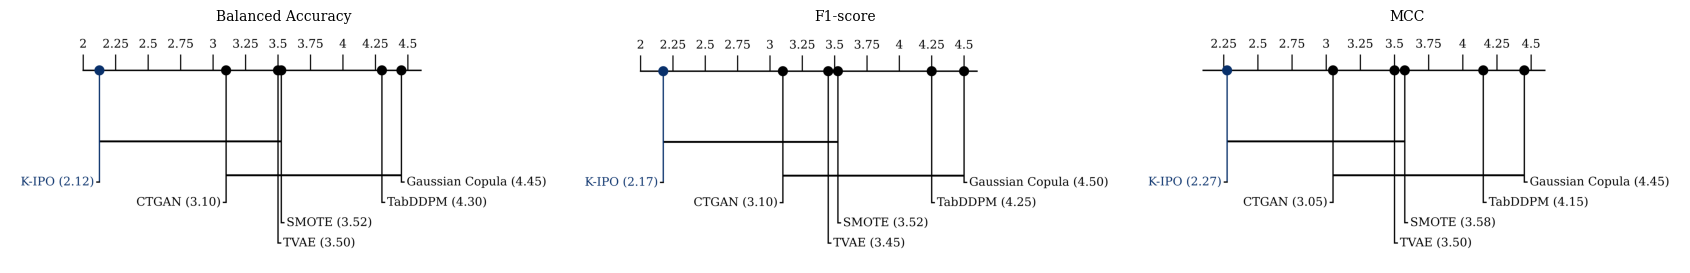

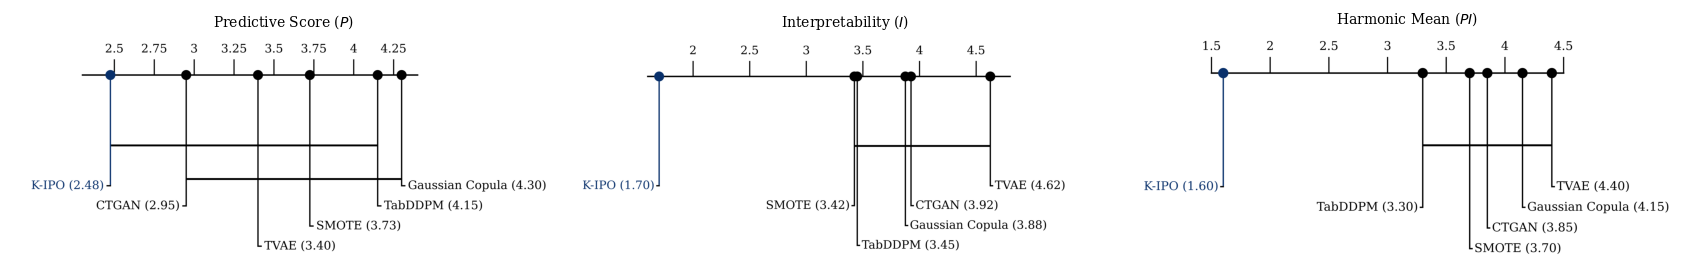

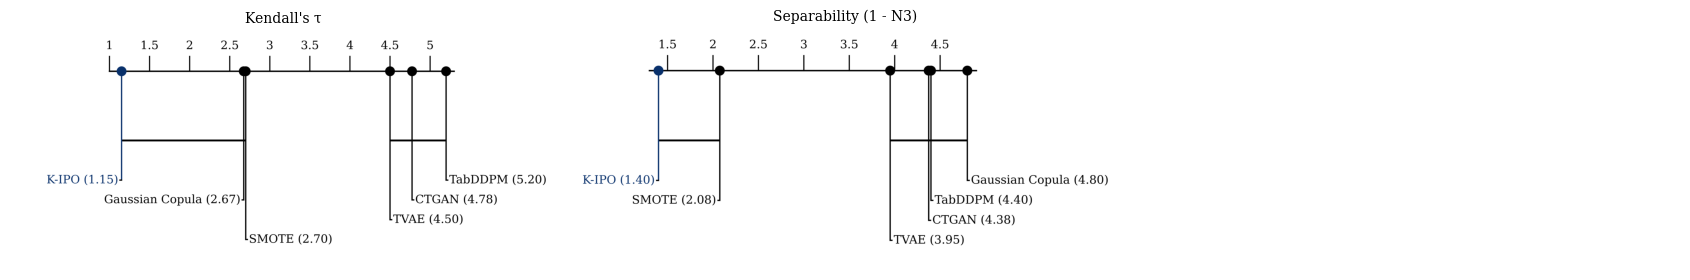

In [ ]:
title_map = {
    "balancedacc": "Balanced Accuracy",
    "f1": "F1-score",
    "mcc": "MCC",
    "predictivescore": r"Predictive Score ($P$)",
    "interpretability": r"Interpretability ($I$)",
    "harmonicmean_pi": r"Harmonic Mean (${PI}$)",
    "kendall_tau": "Kendall's τ",
    "separability_1-n3": "Separability (1 - N3)"
}

cd_dir = Path(os.path.join(STATS_DIR, "critical_diagrams", "png"))

cols = 3; names = list(title_map.keys())

print("[Manuscript] Figure 5: Critical difference diagrams from Nemenyi post-hoc tests on predictive, interpretability, and structural metrics")

for i in range(0, len(names), cols):
    batch = names[i:i + cols]

    fig, axes = plt.subplots(1, cols, figsize = (17, 2.8))

    for ax, name in zip(axes, batch):
        img_path = cd_dir / f"{name}.png"

        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(title_map[name], fontsize = 10)
        ax.axis("off")

    for ax in axes[len(batch):]:
        ax.axis("off")

    plt.tight_layout(); plt.show()